# MountainCar — foundation models as dynamics models

One environment, the same structure as every other notebook in
`experiments/dyna_standard`: only the environments differ.

Everything below is read from `mountaincar/results/*.csv`, produced by

```
python experiments/dyna_standard/mountaincar/mountaincar.py   # this environment
python experiments/dyna_standard/run_all.py               # all of them
```

**1** the environment · **2b** the action probe under four presentations ·
**5** the hyperparameter study · **6** context and data budget · **7** multi-step
rollout · **8** the rollout as states. What runs, and which models appear in §6 and §7, is set in `config.py`.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "config.py").exists())
sys.path.insert(0, str(ROOT))

import config
import pipeline
import plots
import tables

ENVS = ["MountainCar-v0"]
FIGDIR = Path.cwd() / "figures"
COMPUTE_IF_MISSING = False  # True: compute a missing stage here instead of failing

probe = pipeline.load_many(ENVS, "probe", COMPUTE_IF_MISSING)
grid = pipeline.load_many(ENVS, "grid", COMPUTE_IF_MISSING)
rollout = pipeline.load_many(ENVS, "rollout", COMPUTE_IF_MISSING)
traj = pipeline.load_many(ENVS, "traj", COMPUTE_IF_MISSING)

print(f"envs     {ENVS}")
print(f"models   {list(config.MODELS)}")
print(f"in the last two figures  {config.PLOT_MODELS}")
print(f"figures -> {FIGDIR}")

envs     ['MountainCar-v0']
models   ['Chronos-2 S', 'Chronos-2 L', 'Chronos-2 L-syn', 'Chronos-2 S (level)', 'Moirai', 'MLP', 'VARX']
in the last two figures  ['Chronos-2 S', 'Chronos-2 S (level)', 'Chronos-2 L', 'Chronos-2 L-syn', 'Moirai', 'MLP', 'VARX']
figures -> c:\Users\johan\Desktop\tsfm-rl\experiments\dyna_standard\mountaincar\figures


## 1  The environment

One episode per environment: every observation channel, and the action underneath.
The integrated channels — velocities and angular rates — are the ones a forecaster
has to be handed as increments, which is what §2b tests.

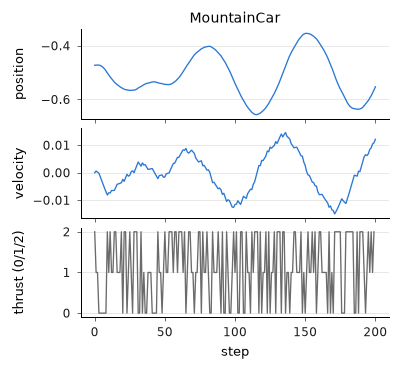

Figure fig1_environments. One episode per environment under a uniform-random policy. Rows are observation channels, the bottom row in each column is the action. The integrated channels (velocities, angular rates) are the ones that must be passed as increments.



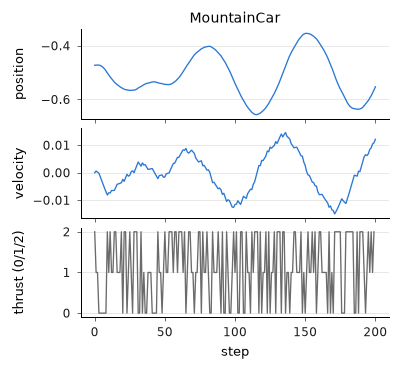

In [2]:
plots.fig_environments(ENVS, FIGDIR)

## 2b  Out of the box, and what fixes it

Hold the context fixed, sweep the next action over a grid, and plot how far the
predicted next value moves on the channel the action drives. The dashed reference
is the real environment stepped from the same states. A flat line means the model
forecast the same thing whatever action it was told was coming — not a weak
effect, no effect.

Four presentations of the *same* trajectory:

| | integrated channels | resolution |
|---|---|---|
| **levels** | as observed | as observed |
| **+ differencing** | as increments, re-integrated after | as observed |
| **+ stretching** | as observed | resampled $r$-fold |
| **both** | as increments | resampled $r$-fold |

States, actions and contexts are byte-identical across the four; only the
representation changes, so whatever the panels show is a fact about the model
rather than about the environment. The stretch factor is `config.DEFAULT_R`;
§5 sweeps it properly.

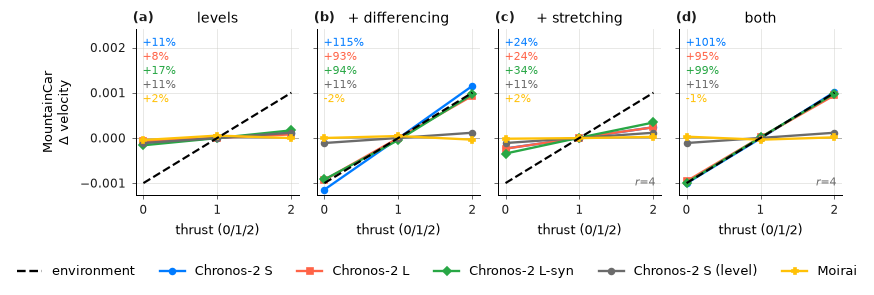

Figure fig2b_transforms. The same probe, the same contexts, the same models -- only the presentation of the trajectory changes. Each panel sweeps the next action and plots the mean shift in the predicted next value, centred on the middle action; the dashed line is the real environment stepped from the same states, so a flat curve means the action was ignored. Percentages are the recovered slope as a share of the environment's, in each model's colour.



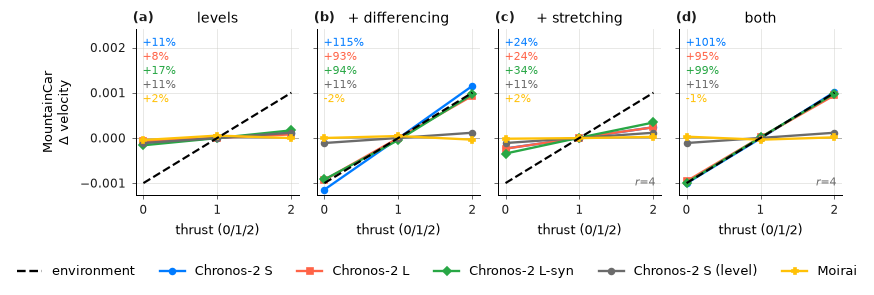

In [3]:
plots.fig_probe(probe, ENVS, FIGDIR)

## 5  Hyperparameter study

Every model, every variant, every budget — one one-step NMSE per cell.

| | the model's hyperparameter | values |
|---|---|---|
| Chronos-2, Moirai | presentation × stretch factor | {levels, differenced} × {1, 2, 4, 8, 16} |
| MLP, VARX | history length | lag 1, 4, 16 |

$N$ means the same thing on both sides — context steps for a foundation model,
training transitions for a fitted one — drawn from episodes of the same length
under the same policy. Stretching does not count against the budget ($N$ real
samples become $(N-1)r+1$ tokens, a processing choice) but it does consume the
context.

The figure sweeps the stretch factor at one budget (`config.STRETCH_BUDGET`), one
curve per model, with the reference model on levels as the dashed open curve. The
table below it is the whole grid; the marked row is the variant §6–§8 use.

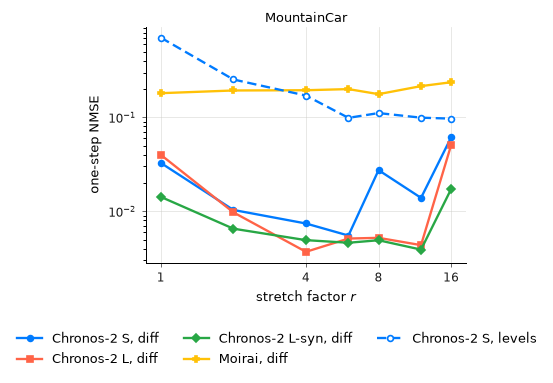

Figure fig5_stretch. One-step error against the stretch factor at $N$=256. Filled markers are the differenced presentation, the open dashed curve is the same model on levels. Stretching is a change of resolution, not of information: N real samples become $(N-1)r+1$ tokens.



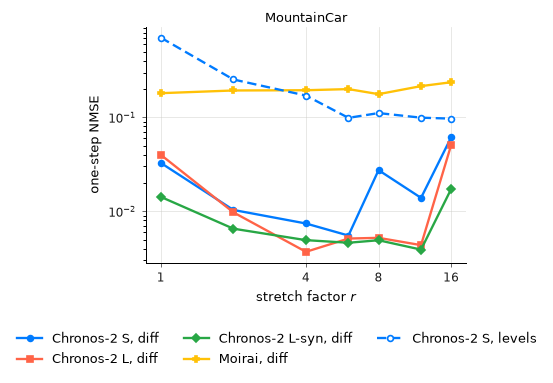

In [4]:
plots.fig_stretch(grid, ENVS, FIGDIR)

A blank cell is a configuration that is **not defined** at that budget,
not one that scored badly: a stretched context that would overflow the model's
window, a VARX with more parameters than design rows, or a Moirai whose context is
shorter than its own horizon requirement — on the `auto` patch path it needs
$(N-1)r+1-d > rH$, so at $N=2$ it runs on levels but not differenced.

In [5]:
for env_id in ENVS:
    print(f"=== {env_id} ===")
    display(tables.show(tables.table_grid(grid, env_id)))

=== MountainCar-v0 ===


## 5b  The configuration sections 6-8 are drawn in

`source` is `selected` where the section 5 rule picked it and `manual` where
`config.PLOT_VARIANTS` overrode it. Both section 6 and section 7 apply this when
they are drawn -- `grid.csv` and `rollout.csv` each hold every variant -- so
changing it never costs a re-run.

In [6]:
display(pipeline.selection(ENVS))

,env,model,variant,presentation,r,lag,source,mean_rank,geo_nmse
0,MountainCar-v0,Chronos-2 S,Chronos-2 S diff r=2,diff,2,-1,selected,4.538462,0.019904
1,MountainCar-v0,Chronos-2 L,Chronos-2 L diff r=4,diff,4,-1,selected,4.846154,0.015721
2,MountainCar-v0,Chronos-2 L-syn,Chronos-2 L-syn diff r=2,diff,2,-1,selected,4.615385,0.018164
3,MountainCar-v0,Chronos-2 S (level),Chronos-2 S (level) level r=1,level,1,-1,selected,1.000000,0.810294
4,MountainCar-v0,Moirai,Moirai diff r=1,diff,1,-1,selected,4.916667,0.201876
5,MountainCar-v0,MLP,MLP lag 1,-,0,1,selected,1.333333,0.084635
6,MountainCar-v0,VARX,VARX lag 1,-,0,1,selected,1.500000,0.155563


### 6a  Does the configuration matter?

Every variant of every model, from `grid.csv`, one panel per model. Read this
before the combined figure below: if a model's own variants spread wider than
the gap between models, the combined figure is mostly reporting a
hyperparameter choice.

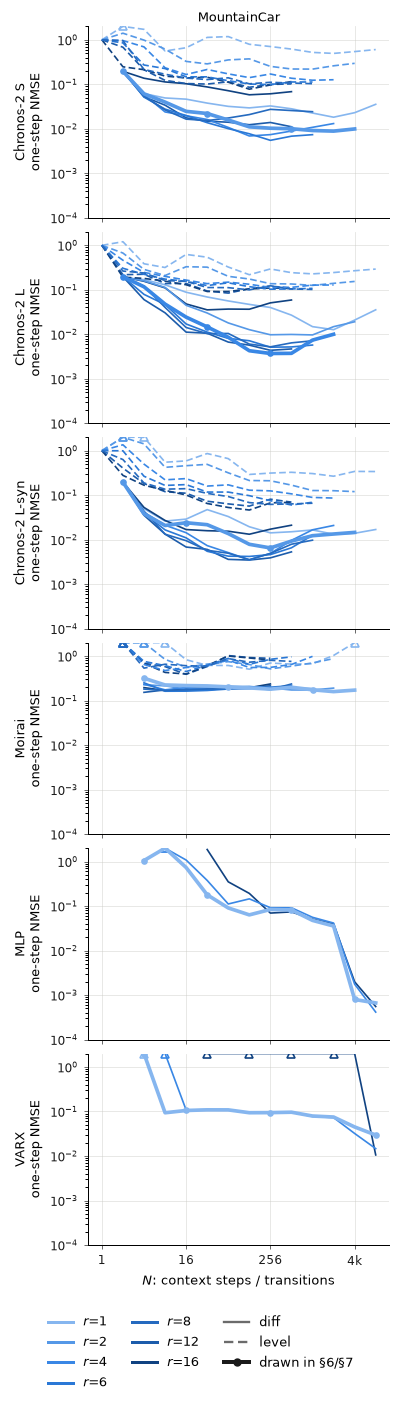

Figure fig6a_scaling_configs. Every configuration of every model against the data budget, one panel per model. Lightness is the sweep value -- the stretch factor $r$ for the foundation models, the history length for the trained ones -- and the dash is the presentation; the heavy marked curve is the one the combined figure draws. Read it for whether the spread between a model's own variants is larger or smaller than the gap between models.



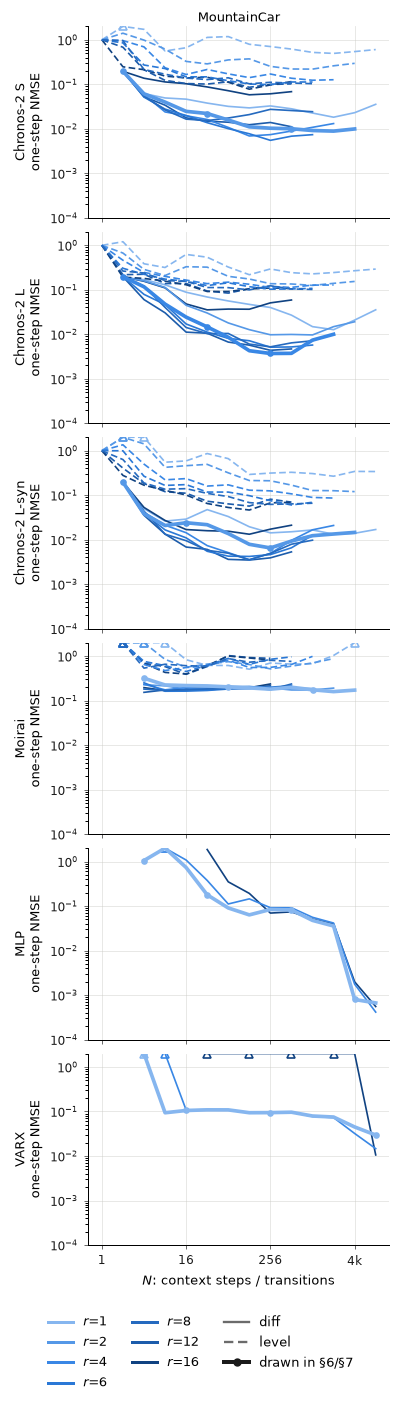

In [7]:
plots.fig_scaling_configs(grid, ENVS, FIGDIR)

### Choosing what §6 and §7 draw

§6a and §7a above show every configuration of every model. Pick the ones you want
in the combined figures and name them in `config.PLOT_VARIANTS` (in `config.py`),
per environment or under `None` for all of them:

```python
PLOT_VARIANTS = {
    None:          {"Chronos-2 S": dict(presentation="diff", r=6)},
    "Pendulum-v1": {"Chronos-2 L": dict(presentation="diff", r=12)},
    "CartPole-v1": {"MLP": dict(lag=4)},
}
```

Anything left out keeps the automatic §5 selection. Both §6 and §7 read this at
draw time and every variant is already measured, so changing it is an edit plus a
re-run of the cells below — never a re-run of a stage. A variant a model does not
have raises and names the ones it does.

Edit `config.py`, then run the cell below to reload it and check the result.

In [8]:
import importlib

importlib.reload(config)
display(pipeline.selection(ENVS))

,env,model,variant,presentation,r,lag,source,mean_rank,geo_nmse
0,MountainCar-v0,Chronos-2 S,Chronos-2 S diff r=2,diff,2,-1,selected,4.538462,0.019904
1,MountainCar-v0,Chronos-2 L,Chronos-2 L diff r=4,diff,4,-1,selected,4.846154,0.015721
2,MountainCar-v0,Chronos-2 L-syn,Chronos-2 L-syn diff r=2,diff,2,-1,selected,4.615385,0.018164
3,MountainCar-v0,Chronos-2 S (level),Chronos-2 S (level) level r=1,level,1,-1,selected,1.000000,0.810294
4,MountainCar-v0,Moirai,Moirai diff r=1,diff,1,-1,selected,4.916667,0.201876
5,MountainCar-v0,MLP,MLP lag 1,-,0,1,selected,1.333333,0.084635
6,MountainCar-v0,VARX,VARX lag 1,-,0,1,selected,1.500000,0.155563


## 6  Context and data budget

$N$ swept from a single sample to a full context, each model in the configuration
§5 selected, so a panel carries a handful of curves instead of forty. For the
foundation models $N$ is the whole context, for the others the number of
transitions fitted on. The models drawn are `config.PLOT_MODELS`.

Read it for **where the curves cross**: that is the number of transitions the
pretrained model saves you, and it is the one number here a practitioner can act
on directly.

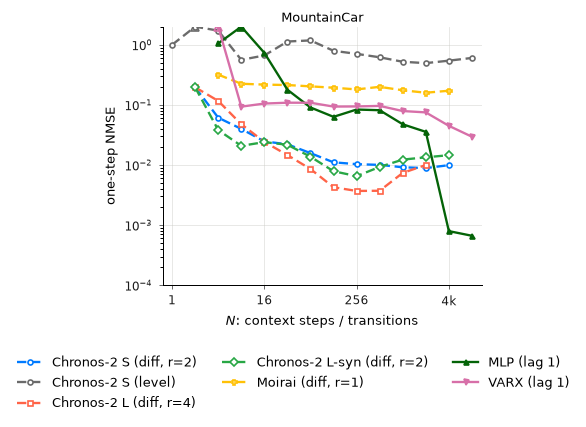

Figure fig6_scaling. How much data each model gets, on one axis, each model in the configuration named in its legend entry -- chosen off §6a, and changed by editing config.PLOT_VARIANTS rather than by re-measuring anything. A curve ends where its stretched context stops fitting. For the foundation models $N$ is the whole context; for the others it is the number of transitions fitted on, drawn from episodes of the same length under the same policy.



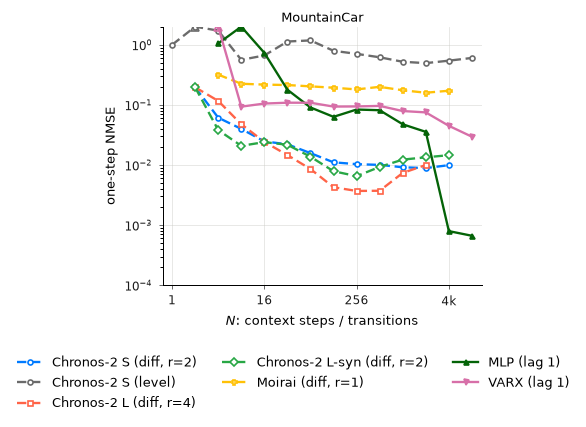

In [9]:
plots.fig_scaling(grid, ENVS, FIGDIR)

### 7a  Does the configuration matter over the horizon?

The same sweep against `h`. Differencing is an integration -- the increments are
summed with no re-anchoring -- so a variant that wins at `h=1` need not still be
winning later, and this is the figure that shows whether it does.

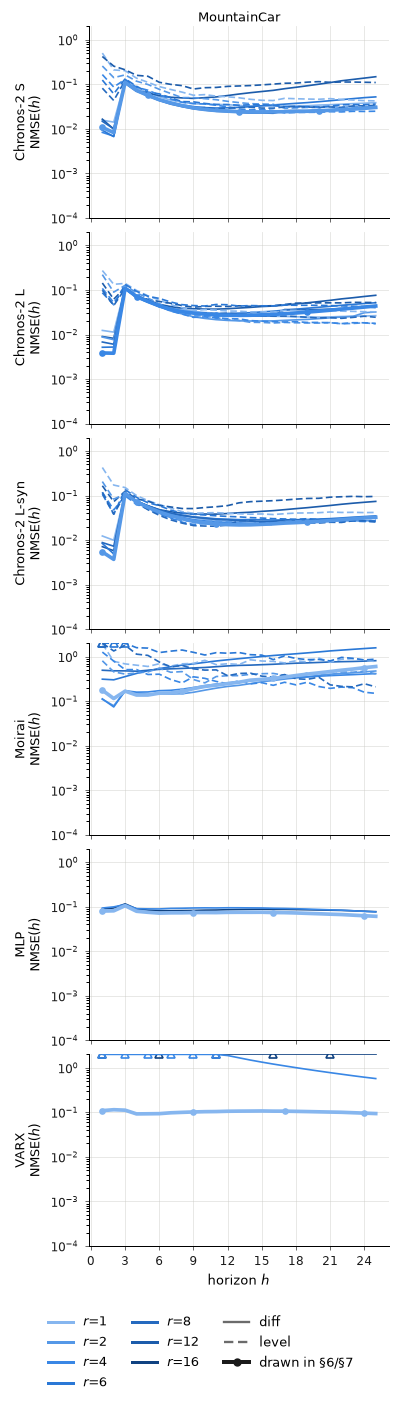

Figure fig7a_rollout_configs. Every configuration of every model over the horizon, at $N$=512, one panel per model. Lightness is the sweep value -- the stretch factor $r$ for the foundation models, the history length for the trained ones -- and the dash is the presentation; the heavy marked curve is the one the combined figure draws. Persistence sits at 1 at every $h$, so a curve crossing that line has stopped being useful for planning; where a model's own variants cross each other is where the configuration the one-step sweep prefers stops being the right one.



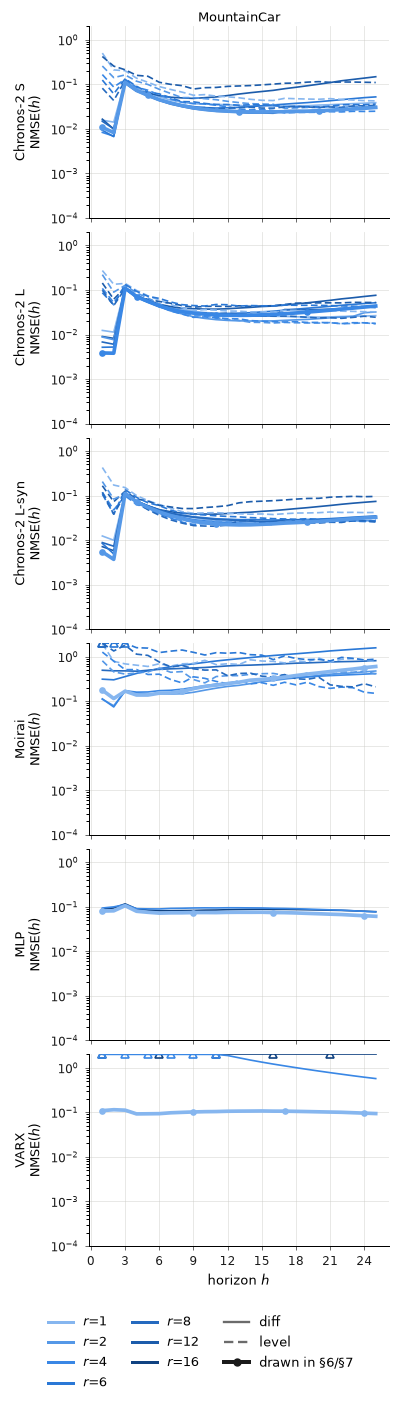

In [10]:
plots.fig_rollout_configs(rollout, ENVS, FIGDIR)

## 7  Multi-step rollout

Open loop to $h=20$ with the true action sequence known throughout — the
favourable case for every model — repeated at three data budgets, because "which
model rolls out best" has no answer independent of how much data each model had.

Normalisation is per horizon by the mean square of $s_{t+h}-s_t$, so persistence
sits at 1 for every $h$: **where a curve crosses that line the model has stopped
being useful for planning**, and that crossing is the number an MPC or Dyna loop
actually needs.

   note: Chronos-2 L on MountainCar-v0 has no rows for 'Chronos-2 L diff r=4' (have: ['Chronos-2 L diff r=1', 'Chronos-2 L diff r=2', 'Chronos-2 L level r=1', 'Chronos-2 L level r=2']) -- not drawn
   note: Chronos-2 S on MountainCar-v0 has no rows for 'Chronos-2 S diff r=2' (have: ['Chronos-2 S diff r=1', 'Chronos-2 S level r=1']) -- not drawn
   note: Chronos-2 L on MountainCar-v0 has no rows for 'Chronos-2 L diff r=4' (have: ['Chronos-2 L diff r=1', 'Chronos-2 L level r=1']) -- not drawn
   note: Chronos-2 L-syn on MountainCar-v0 has no rows for 'Chronos-2 L-syn diff r=2' (have: ['Chronos-2 L-syn diff r=1', 'Chronos-2 L-syn level r=1']) -- not drawn


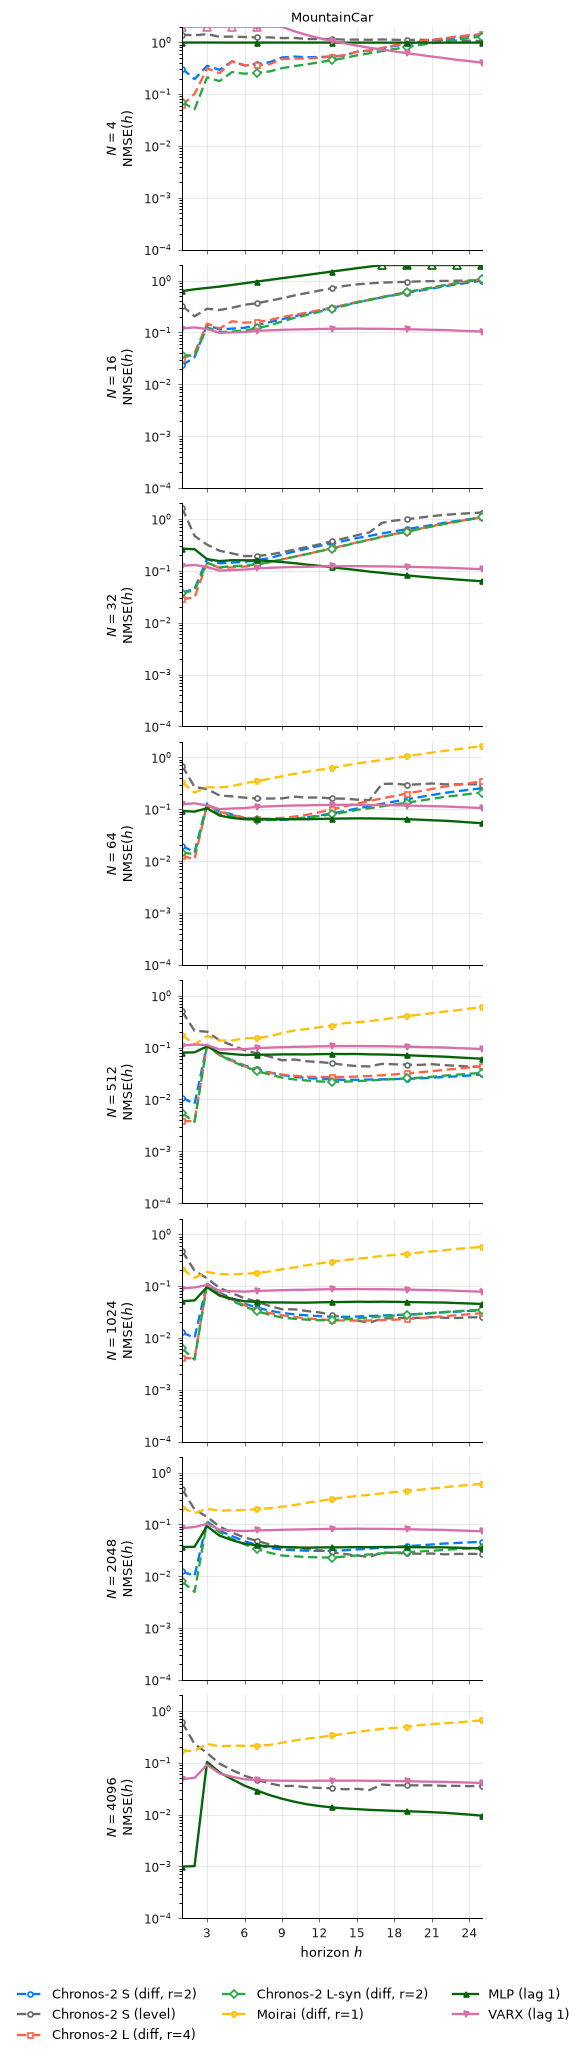

Figure fig7_rollout. Open-loop rollout to $h=25$ with the true actions known, repeated at 8 data budgets. Every model is drawn in one configuration, named in the legend; the full sweep behind it is §7a. A row is one budget: the trained models were fitted on $N$ transitions, the foundation models given $N$ steps of context, stretched by the $r$ its legend entry names.



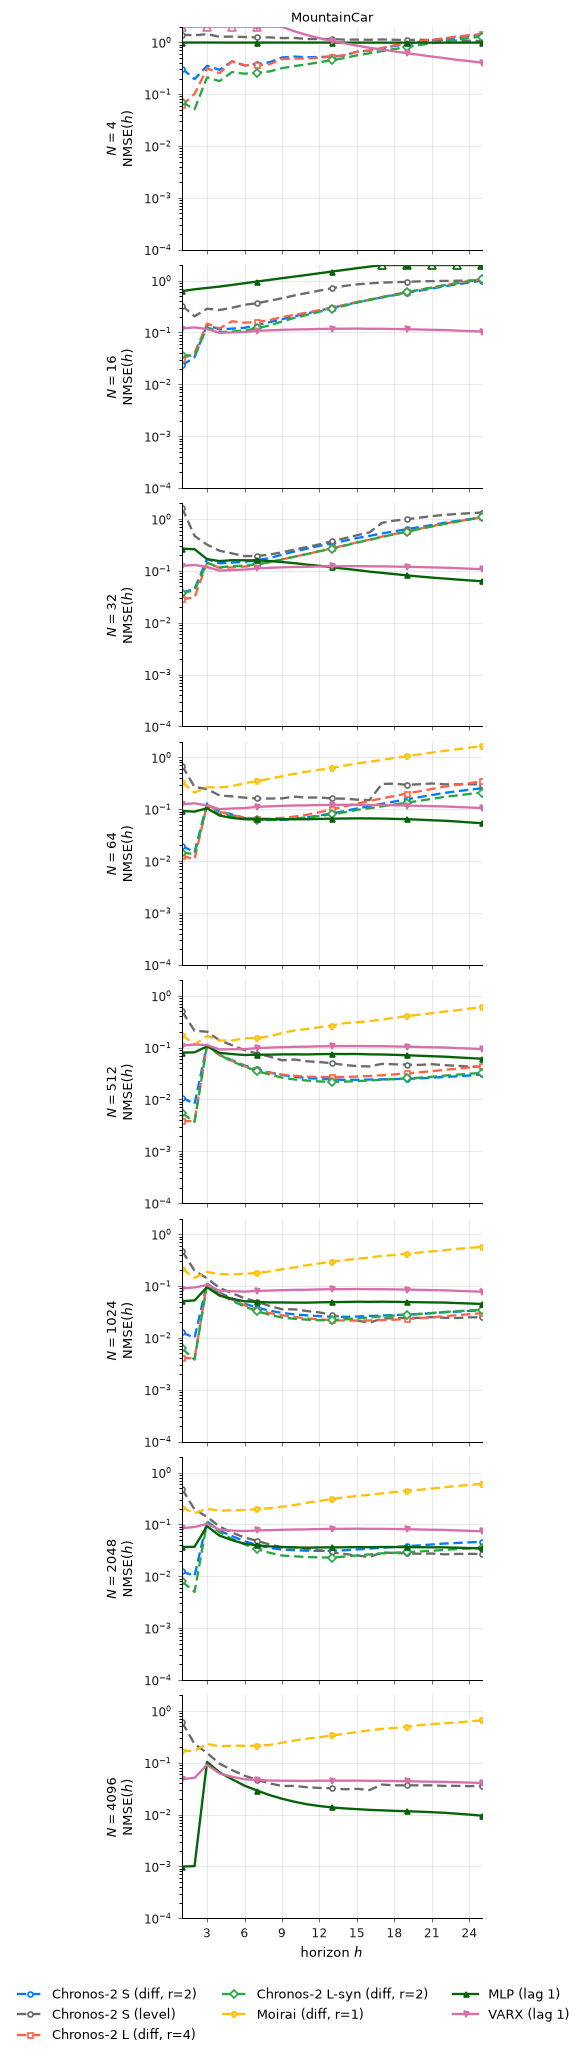

In [11]:
plots.fig_rollout(rollout, ENVS, FIGDIR)

## 8  The rollout as states

The same rollout as §7, but plotted as the states themselves. An error curve says
how wrong a model is; this says *how* — a phase lag, a damped amplitude and a
drift off the manifold all look alike in NMSE and quite different here. Black is
the environment, dashed is each model, one panel row per observation channel.

These states are kept by the rollout itself, for the budgets in
`config.TRAJ_BUDGETS` — no stage of its own. Two knobs, both read when the
figure is drawn: **which N** (`config.TRAJ_BUDGET`, or `budget=` below) and
**which configuration** (the same `config.PLOT_VARIANTS` §6 and §7 use). Asking
for an N or a variant the rollout never measured raises and says what is
available, rather than dropping the model out of the panel.

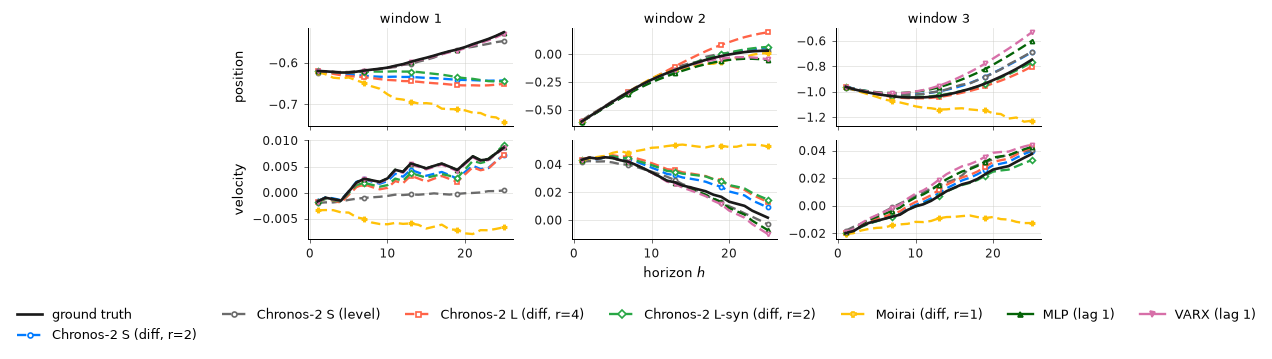

Figure fig8_trajectories_mountaincar. Open-loop rollout on MountainCar as states rather than as an error, at $N$=512 with the true actions known throughout. Black is the environment, dashed is each model. Rows are observation channels, columns are windows from the same evaluation set section 7 scores.



In [12]:
for env_id in ENVS:
    plots.fig_trajectories(traj, env_id, FIGDIR, budget=config.TRAJ_BUDGET)